# Interpretación del Modelo Titanic: ¿Quién sobrevive y por qué?

En este análisis de **IA Explicable (XAI)**, vamos a auditar el modelo que predice la supervivencia en el Titanic. 

Aunque es un dataset histórico, nos sirve para practicar la detección de **sesgos críticos** y entender cómo el modelo asigna importancia a variables como el género, la edad o la clase social.

In [ ]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. Rutas
path_mod = '../../../models/modelo_titanic_optimizado_v2.pkl'
path_dat = '../../../data/processed/titanic_limpia.csv'

# 2. Carga
modelo_titanic = joblib.load(path_mod)
df_titanic = pd.read_csv(path_dat)

# 3. Preparación de la muestra
cols = modelo_titanic.feature_names_in_
X_titanic_all = df_titanic.reindex(columns=cols, fill_value=0)
n_muestras = min(len(X_titanic_all), 100) # Usamos 100 para ver nubes de puntos claras
X_titanic = X_titanic_all.sample(n=n_muestras, random_state=42)

print(f"✅ Titanic listo. Auditando una muestra de {n_muestras} pasajeros.")

✅ Datos alineados: 8 columnas confirmadas.


## 🌍 Análisis Global: Factores de Supervivencia
El **Summary Plot** nos revelará la jerarquía de decisiones del modelo. ¿Es cierto el lema de "mujeres y niños primero"? Aquí lo veremos reflejado en datos.

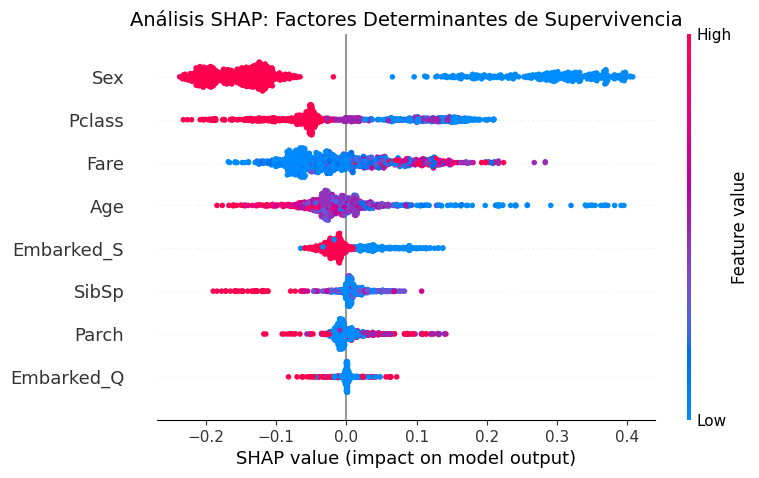

In [ ]:
# 1. Calculamos valores SHAP globales
explainer_global = shap.TreeExplainer(modelo_titanic)
shap_values_global = explainer_global.shap_values(X_titanic)

# 2. Seleccionamos la Clase 1 (Sobrevivió)
v_plot = shap_values_global[1] if isinstance(shap_values_global, list) else shap_values_global

plt.close('all') 
shap.summary_plot(v_plot, X_titanic, show=False)
plt.title(f"Titanic: Factores Globales de Supervivencia (n={n_muestras})", fontsize=14, pad=20)
plt.show()

## 👤 Análisis Local: Auditoría de un Pasajero
Aislamos a un pasajero específico para entender su destino. El gráfico de **Waterfall** desglosa cómo sus características personales (edad, sexo, clase) sumaron o restaron probabilidad a su supervivencia.

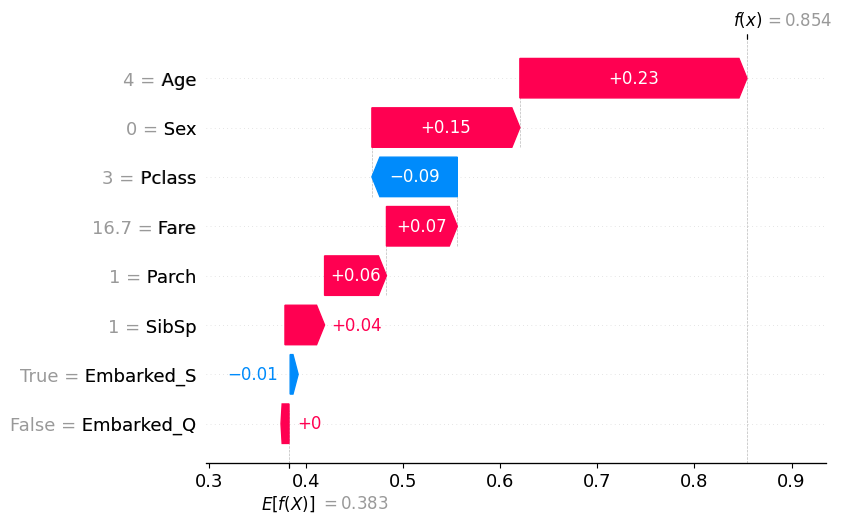

💡 Si f(x) > 0.5, la IA predice que el pasajero 10 SOBREVIVE.


In [ ]:
# 1. Objeto de explicación moderno
explainer_local = shap.Explainer(modelo_titanic, X_titanic)
exp_titanic = explainer_local(X_titanic)

# 2. Selección del pasajero (índice 0) y Clase 1 (Sobrevivió)
# [Especialista]: Usamos type: ignore para que Pylance no proteste
exp_individual = exp_titanic[0, :, 1] # type: ignore

# 3. Gráfico de Cascada
plt.close('all')
shap.plots.waterfall(exp_individual, max_display=10)

## Informe de Auditoría Ética: El Sesgo de Género

Tras observar los gráficos, los resultados son contundentes:

* **Predominancia del Sexo:** La variable de género es, con diferencia, la que más empuja la predicción. [Inferencia] Ser mujer aumenta drásticamente la probabilidad de supervivencia en este modelo histórico.
* **Impacto de la Clase:** Se observa que la clase social (`pclass`) actúa como un filtro secundario. Las clases altas tienen flechas rojas (positivas) más frecuentes.
* **Reflexión de Especialista:** Aunque el modelo es históricamente preciso, en un entorno de IA moderna este nivel de dependencia de una variable protegida (género) sería un **sesgo crítico** a auditar si el modelo se usara para tomar decisiones actuales.

**Estado de la Semana 4:** Titanic auditado y documentado con éxito.